# 01 - Entendimento dos Dados

Objetivo: carregar os arquivos brutos do Kaggle, validar disponibilidade, unir as fontes e inspecionar qualidade básica antes de modelar.

Boas práticas usadas aqui:

- Reutilizar o código de produção em `src/`.
- Não criar features de modelo nesta etapa.
- Confirmar distribuição da variável alvo e cobertura temporal.
- Evitar usar acurácia como referência de performance.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('D:/developer/workspace_python/financial_transactions_pipeline')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config.settings import Settings
from src.data.load_data import RawDataRepository
from src.data.merge_data import FraudDataMerger
from src.features.cleaning import FraudDataCleaner

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

settings = Settings(project_root=PROJECT_ROOT)
settings.raw_data_dir

WindowsPath('D:/developer/workspace_python/financial_transactions_pipeline/data/raw')

## 1. Verificar arquivos esperados

Baixe o dataset do Kaggle e coloque os arquivos em `data/raw`.

In [3]:
expected_files = [
    "transactions_data.csv",
    "cards_data.csv",
    "users_data.csv",
    "mcc_codes.json",
    "train_fraud_labels.json",
]

file_status = pd.DataFrame(
    {
        "file": expected_files,
        "exists": [(settings.raw_data_dir / name).exists() for name in expected_files],
        "path": [str(settings.raw_data_dir / name) for name in expected_files],
    }
)
file_status

,file,exists,path
0,transactions_data.csv,True,D:\developer\workspace_python\financial_transa...
1,cards_data.csv,True,D:\developer\workspace_python\financial_transa...
2,users_data.csv,True,D:\developer\workspace_python\financial_transa...
3,mcc_codes.json,True,D:\developer\workspace_python\financial_transa...
4,train_fraud_labels.json,True,D:\developer\workspace_python\financial_transa...


## 2. Carregar fontes brutas

In [4]:
repo = RawDataRepository(settings)
raw = repo.load_all()

shape_summary = []
for name, value in raw.items():
    if isinstance(value, pd.DataFrame):
        shape_summary.append({"source": name, "rows": value.shape[0], "columns": value.shape[1]})
    else:
        shape_summary.append({"source": name, "rows": len(value) if hasattr(value, "__len__") else None, "columns": None})

pd.DataFrame(shape_summary)

2026-06-13 12:14:30 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\transactions_data.csv
2026-06-13 12:15:13 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\cards_data.csv
2026-06-13 12:15:13 | INFO | src.data.load_data | Carregando CSV de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\users_data.csv
2026-06-13 12:15:13 | INFO | src.data.load_data | Carregando JSON de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\mcc_codes.json
2026-06-13 12:15:13 | INFO | src.data.load_data | Carregando JSON de local: D:\developer\workspace_python\financial_transactions_pipeline\data\raw\train_fraud_labels.json


,source,rows,columns
0,transactions,13305915,12.0
1,cards,6146,13.0
2,users,2000,14.0
3,mcc,109,NaN
4,labels,1,NaN


In [5]:
raw["transactions"].head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


## 3. Unir dados e limpar campos básicos

In [6]:
merged = FraudDataMerger(settings).merge(
    transactions=raw["transactions"],
    cards=raw["cards"],
    users=raw["users"],
    mcc_codes=raw["mcc"],
    labels=raw["labels"],
)
cleaned = FraudDataCleaner(settings).fit_transform(merged)

cleaned.shape, cleaned.head()

2026-06-13 12:16:43 | INFO | src.data.merge_data | Dataset consolidado: 8914963 linhas, 39 colunas


D:\developer\workspace_python\financial_transactions_pipeline\src\features\cleaning.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")
D:\developer\workspace_python\financial_transactions_pipeline\src\features\cleaning.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], errors="coerce")


((8914963, 39),
   transaction_id                date  client_id  card_id  amount  \
 0        7475327 2010-01-01 00:01:00       1556     2972  -77.00   
 1        7475328 2010-01-01 00:02:00        561     4575   14.57   
 2        7475329 2010-01-01 00:02:00       1129      102   80.00   
 3        7475332 2010-01-01 00:06:00        848     3915   46.41   
 4        7475333 2010-01-01 00:07:00       1807      165    4.81   
 
             use_chip  merchant_id merchant_city merchant_state      zip   mcc  \
 0  Swipe Transaction        59935        Beulah             ND  58523.0  5499   
 1  Swipe Transaction        67570    Bettendorf             IA  52722.0  5311   
 2  Swipe Transaction        27092         Vista             CA  92084.0  4829   
 3  Swipe Transaction        13051       Harwood             MD  20776.0  5813   
 4  Swipe Transaction        20519         Bronx             NY  10464.0  5942   
 
   errors  is_fraud  client_id_card  card_brand        card_type  \
 0    

## 4. Distribuição da fraude

Fraude costuma ser um problema desbalanceado. Por isso, acurácia não é uma métrica principal adequada.

In [7]:
target = settings.target_column
target_distribution = (
    cleaned[target]
    .value_counts(dropna=False)
    .rename_axis("is_fraud")
    .reset_index(name="count")
)
target_distribution["rate"] = target_distribution["count"] / target_distribution["count"].sum()
target_distribution

,is_fraud,count,rate
0,0,8901631,0.998505
1,1,13332,0.001495


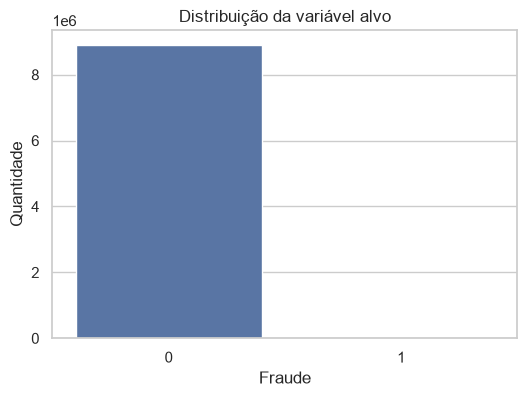

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_distribution, x="is_fraud", y="count", ax=ax)
ax.set_title("Distribuição da variável alvo")
ax.set_xlabel("Fraude")
ax.set_ylabel("Quantidade")
plt.show()

## 5. Cobertura temporal e taxa de fraude por mês

In [9]:
from src.data.merge_data import first_existing

time_col = first_existing(cleaned.columns, settings.time_column_candidates)
time_col

'date'

In [10]:
cleaned[time_col].agg(["min", "max"])

min   2010-01-01 00:01:00
max   2019-10-31 23:57:00
Name: date, dtype: datetime64[us]

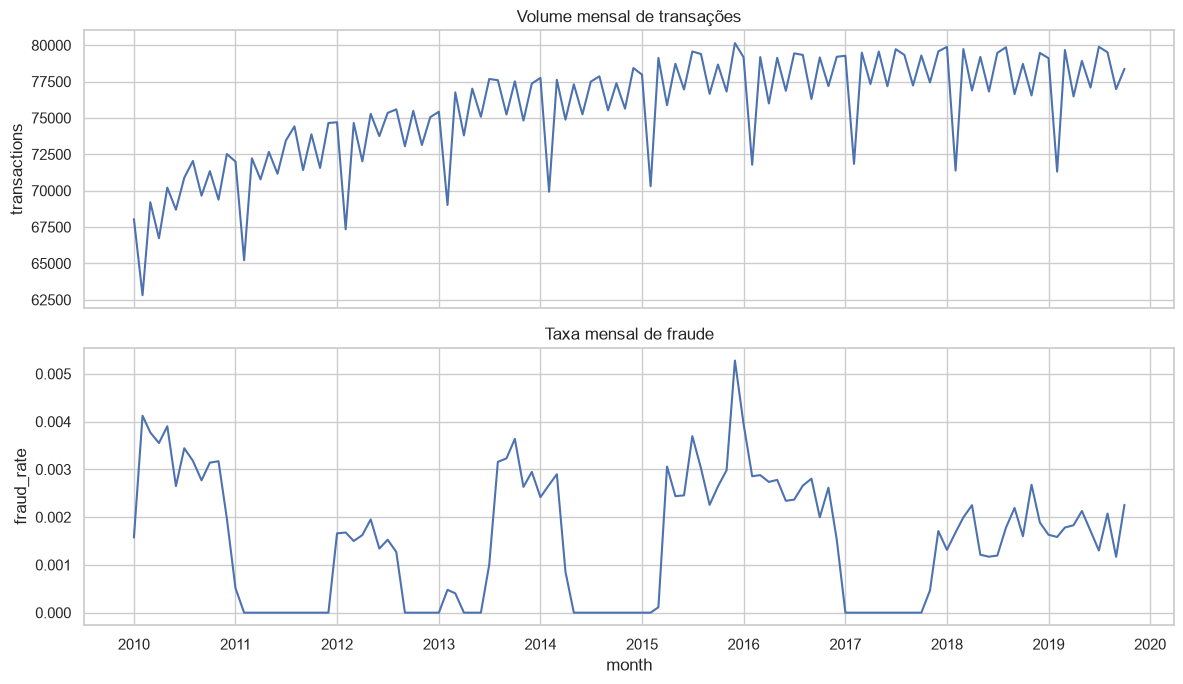

In [11]:
monthly = (
    cleaned.assign(month=cleaned[time_col].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(transactions=(target, "size"), fraud_rate=(target, "mean"))
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sns.lineplot(data=monthly, x="month", y="transactions", ax=axes[0])
sns.lineplot(data=monthly, x="month", y="fraud_rate", ax=axes[1])
axes[0].set_title("Volume mensal de transações")
axes[1].set_title("Taxa mensal de fraude")
axes[1].set_ylabel("fraud_rate")
plt.tight_layout()
plt.show()

## 6. Qualidade dos dados

Inspecione nulos, tipos e cardinalidade. Alta cardinalidade em identificadores crus não deve entrar como feature.

In [12]:
quality = pd.DataFrame(
    {
        "dtype": cleaned.dtypes.astype(str),
        "missing_rate": cleaned.isna().mean(),
        "nunique": cleaned.nunique(dropna=True),
    }
).sort_values("missing_rate", ascending=False)
quality.head(30)

,dtype,missing_rate,nunique
errors,str,0.984098,22
zip,float64,0.124216,24586
merchant_state,str,0.117540,199
card_id,int64,0.000000,4070
transaction_id,str,0.000000,8914963
date,datetime64[us],0.000000,3680988
client_id,int64,0.000000,1219
merchant_id,int64,0.000000,66537
use_chip,str,0.000000,3
amount,float64,0.000000,70638
